LOAD DATASET

In [1]:
import pandas as pd

# Load the dataset
file_path = "C:\\Users\\kiran\\Downloads\\tripadvisor_hotel_reviews.csv" 
data = pd.read_csv(file_path)

# Display the first few rows of the dataset
print("Dataset Preview:")
print(data.head())

# Display dataset information
print("\nDataset Info:")
print(data.info())

Dataset Preview:
                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB
None


Label Creation

In [2]:
# Convert Ratings to Sentiment Labels
def label_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

data['Sentiment'] = data['Rating'].apply(label_sentiment)

# Check the distribution of sentiment labels
print("Sentiment Label Distribution:")
print(data['Sentiment'].value_counts())

# Display updated dataset preview
print("\nUpdated Dataset Preview:")
print(data.head())


Sentiment Label Distribution:
Sentiment
Positive    15093
Negative     3214
Neutral      2184
Name: count, dtype: int64

Updated Dataset Preview:
                                              Review  Rating Sentiment
0  nice hotel expensive parking got good deal sta...       4  Positive
1  ok nothing special charge diamond member hilto...       2  Negative
2  nice rooms not 4* experience hotel monaco seat...       3   Neutral
3  unique, great stay, wonderful time hotel monac...       5  Positive
4  great stay great stay, went seahawk game aweso...       5  Positive


Text Preprocessing & TF-IDF Vectorization

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Step 1: Preprocessing
def preprocess_text(text):
    # Lowercase and remove punctuation (basic preprocessing)
    text = text.lower()
    text = ''.join(char for char in text if char.isalnum() or char.isspace())
    return text

data['Cleaned_Review'] = data['Review'].apply(preprocess_text)

# Step 2: TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)  # Limit features to 5000 for efficiency
X = vectorizer.fit_transform(data['Cleaned_Review'])  # Features (TF-IDF matrix)
y = data['Sentiment']  # Labels

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data Preparation Complete!")
print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")


Data Preparation Complete!
Training Data: (16392, 5000)
Testing Data: (4099, 5000)


In [4]:
import scipy

# Save TF-IDF features to a sparse matrix file
scipy.sparse.save_npz("tfidf_features.npz", X)

# Save the labels to a CSV file
y.to_csv("sentiment_labels.csv", index=False)

print("TF-IDF features and labels have been saved!")


TF-IDF features and labels have been saved!


Class Weights for SVM and Logistic Regression

In [5]:
# Import necessary libraries
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize SVM and Logistic Regression with class_weight='balanced'
svm = SVC(probability=True, class_weight='balanced')
lr = LogisticRegression(class_weight='balanced')

# Initialize Voting Classifier with SVM and Logistic Regression
voting_clf = VotingClassifier(estimators=[('svm', svm), ('lr', lr)], voting='soft')

# Train the model with the original training data
voting_clf.fit(X_train, y_train)

# Evaluate the model
y_pred = voting_clf.predict(X_test)

# Accuracy and Classification Report
accuracy = accuracy_score(y_test, y_pred)
print(f"Ensemble Model Accuracy with Class Weights: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Ensemble Model Accuracy with Class Weights: 0.8446

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.81      0.78       643
     Neutral       0.39      0.36      0.37       437
    Positive       0.93      0.92      0.93      3019

    accuracy                           0.84      4099
   macro avg       0.69      0.70      0.69      4099
weighted avg       0.84      0.84      0.84      4099



SMOTE to Balance Minority Classes

In [6]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE to balance the dataset
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# Check the class distribution after applying SMOTE
print(f"Resampled class distribution: {Counter(y_res)}")

# Train the ensemble model with resampled data
voting_clf.fit(X_res, y_res)

# Evaluate the model
y_pred = voting_clf.predict(X_test)

# Accuracy and Classification Report
accuracy = accuracy_score(y_test, y_pred)
print(f"Ensemble Model Accuracy after SMOTE: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Resampled class distribution: Counter({'Positive': 12074, 'Negative': 12074, 'Neutral': 12074})
Ensemble Model Accuracy after SMOTE: 0.8544

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.80      0.78       643
     Neutral       0.43      0.30      0.35       437
    Positive       0.91      0.95      0.93      3019

    accuracy                           0.85      4099
   macro avg       0.70      0.68      0.69      4099
weighted avg       0.84      0.85      0.85      4099



Combine Class Weights with SMOTE

In [7]:
# Apply SMOTE to balance the dataset first
X_res, y_res = smote.fit_resample(X_train, y_train)

# Initialize SVM and Logistic Regression with class_weight='balanced'
svm = SVC(probability=True, class_weight='balanced')
lr = LogisticRegression(class_weight='balanced')

# Initialize Voting Classifier with SVM and Logistic Regression
voting_clf = VotingClassifier(estimators=[('svm', svm), ('lr', lr)], voting='soft')

# Train the ensemble model with the resampled data
voting_clf.fit(X_res, y_res)

# Evaluate the model
y_pred = voting_clf.predict(X_test)

# Accuracy and Classification Report
accuracy = accuracy_score(y_test, y_pred)
print(f"Ensemble Model Accuracy after SMOTE and Class Weights: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Ensemble Model Accuracy after SMOTE and Class Weights: 0.8544

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.80      0.78       643
     Neutral       0.43      0.30      0.35       437
    Positive       0.91      0.95      0.93      3019

    accuracy                           0.85      4099
   macro avg       0.70      0.68      0.69      4099
weighted avg       0.84      0.85      0.85      4099



Model Evaluation 

c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only 

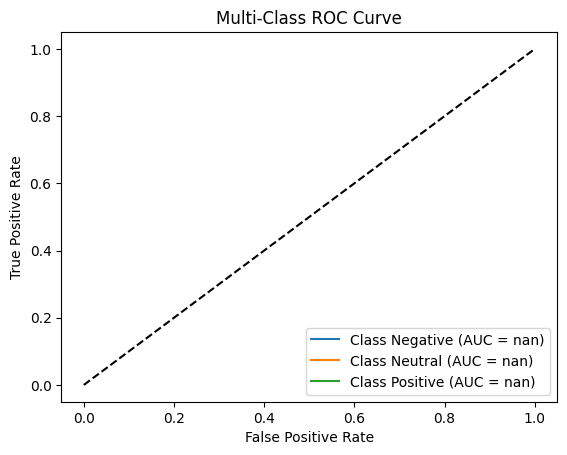

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# Ensure y_test is encoded properly for multi-class ROC calculation
from sklearn.preprocessing import label_binarize
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])  # Assuming 0: Negative, 1: Neutral, 2: Positive

# Compute ROC and AUC for each class
n_classes = y_test_binarized.shape[1]
fpr = {}
tpr = {}
roc_auc = {}

y_prob = voting_clf.predict_proba(X_test)  # Ensure predict_proba is available

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = roc_auc_score(y_test_binarized[:, i], y_prob[:, i])

# Plot ROC Curve for each class
import matplotlib.pyplot as plt
for i, label in enumerate(['Negative', 'Neutral', 'Positive']):
    plt.plot(fpr[i], tpr[i], label=f"Class {label} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend(loc="lower right")
plt.show()



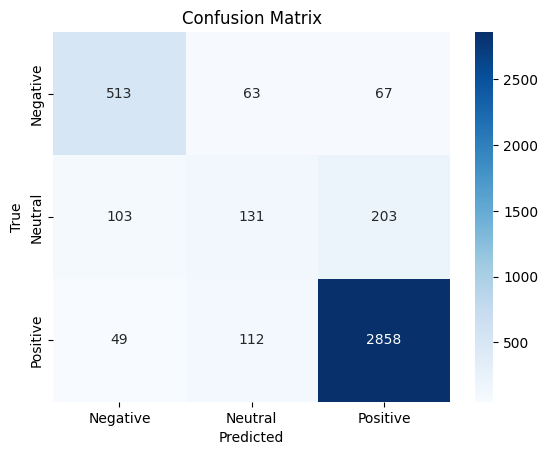


Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.80      0.78       643
     Neutral       0.43      0.30      0.35       437
    Positive       0.91      0.95      0.93      3019

    accuracy                           0.85      4099
   macro avg       0.70      0.68      0.69      4099
weighted avg       0.84      0.85      0.85      4099

Overall Accuracy: 85.44%


c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:379: UndefinedMetricWarning: Only 

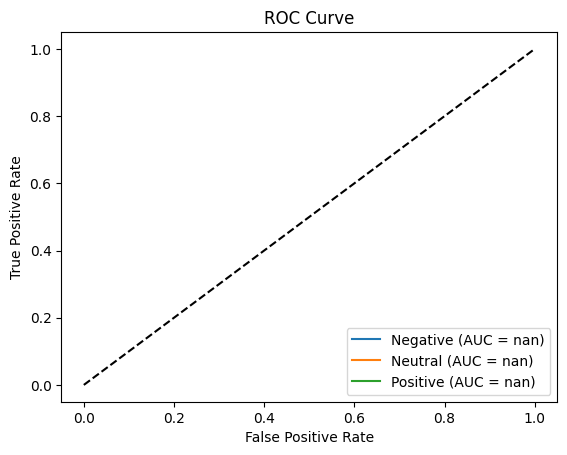

In [10]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

# Predict on the test set
y_pred = voting_clf.predict(X_test)

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 2. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

# 3. Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

# 4. ROC and AUC for Multi-Class
y_test_binarized = label_binarize(y_test, classes=[0, 1, 2])  # Assuming classes: 0: Negative, 1: Neutral, 2: Positive
y_prob = voting_clf.predict_proba(X_test)  # Get predicted probabilities

fpr = {}
tpr = {}
roc_auc = {}
for i in range(3):  # For each class
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = roc_auc_score(y_test_binarized[:, i], y_prob[:, i])

# Plot ROC Curves
for i, label in enumerate(['Negative', 'Neutral', 'Positive']):
    plt.plot(fpr[i], tpr[i], label=f"{label} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


Save the Trained Model

In [11]:
import joblib

# Save the trained ensemble model
model_filename = "opinion_mining_ensemble_model.pkl"
joblib.dump(voting_clf, model_filename)
print(f"Model saved as {model_filename}")

Model saved as opinion_mining_ensemble_model.pkl


Load the Saved Model

In [12]:
# Load the saved model
loaded_model = joblib.load(model_filename)
print("Model loaded successfully!")

Model loaded successfully!


Make Predictions

In [15]:
print("Predictions (raw):", predictions)


Predictions (raw): ['Positive' 'Negative' 'Neutral']


In [18]:
# Example new reviews for prediction
new_reviews = [
    "The hotel was fantastic, very clean and had friendly staff.",
    "Terrible service, I will never stay here again.",
    "It was okay, but nothing special. Room could have been better.",
    "its ok"
]

# Convert new reviews into TF-IDF vectors
new_reviews_tfidf = vectorizer.transform(new_reviews)

# Predict sentiments for new reviews
predictions = loaded_model.predict(new_reviews_tfidf)

# Display predictions
for review, sentiment in zip(new_reviews, predictions):
    print(f"Review: \"{review}\" \nPredicted Sentiment: {sentiment}\n")


Review: "The hotel was fantastic, very clean and had friendly staff." 
Predicted Sentiment: Positive

Review: "Terrible service, I will never stay here again." 
Predicted Sentiment: Negative

Review: "It was okay, but nothing special. Room could have been better." 
Predicted Sentiment: Neutral

Review: "its ok" 
Predicted Sentiment: Neutral

